* https://www.kaggle.com/datasets/abdullahorzan/moodify-dataset
* https://github.com/orzanai/Moodify    
這一個資料集是希望不只透過歌詞和音樂相關的feature來分類音樂。   
希望能推薦更好的音樂。  
大概先進行一部分的區分，建模。  
感覺會花比較多部分在visualize。 
還有進行feature select 和 dimension reduction的嘗試？   
最後感覺使用模型來稍微進行預測？

## feature value description

Labels: {'sad': 0, 'happy': 1, 'energetic': 2, 'calm': 3}

Acousticness: A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic.

Danceability: Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable.

Energy: Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale. Perceptual features contributing to this attribute include dynamic range, perceived loudness, timbre, onset rate, and general entropy.

Instrumentalness: Predicts whether a track contains no vocals. “Ooh” and “aah” sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly “vocal”. The closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content. Values above 0.5 are intended to represent instrumental tracks, but confidence is higher as the value approaches 1.0.

Liveness: Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides a strong likelihood that the track is live.

Loudness: the overall loudness of a track in decibels (dB). Loudness values are averaged across the entire track and are useful for comparing the relative loudness of tracks. Loudness is the quality of a sound that is the primary psychological correlate of physical strength (amplitude). Values typically range between -60 and 0 db.

Speechiness: Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audiobook, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks.

Valence: A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry).

Tempo: The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, the tempo is the speed or pace of a given piece and derives directly from the average beat duration.




https://sites.tufts.edu/eeseniordesignhandbook/2015/music-mood-classification/

## data loading and processing

In [5]:
import pandas as pd
import numpy as np

In [6]:
df_label = pd.read_csv('./Data/278k_labelled_uri.csv')
print(df_label.columns)
df_label.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], inplace=True)
df_label

Index(['Unnamed: 0.1', 'Unnamed: 0', 'duration (ms)', 'danceability', 'energy',
       'loudness', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'spec_rate', 'labels', 'uri'],
      dtype='object')


,duration (ms),danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,spec_rate,labels,uri
0,195000.0,0.611,0.614,-8.815,0.0672,0.01690,0.000794,0.7530,0.520,128.050,3.446154e-07,2,spotify:track:3v6sBj3swihU8pXQQHhDZo
1,194641.0,0.638,0.781,-6.848,0.0285,0.01180,0.009530,0.3490,0.250,122.985,1.464234e-07,1,spotify:track:7KCWmFdw0TzoJbKtqRRzJO
2,217573.0,0.560,0.810,-8.029,0.0872,0.00710,0.000008,0.2410,0.247,170.044,4.007850e-07,1,spotify:track:2CY92qejUrhyPUASawNVRr
3,443478.0,0.525,0.699,-4.571,0.0353,0.01780,0.000088,0.0888,0.199,92.011,7.959809e-08,0,spotify:track:11BPfwVbB7vok7KfjBeW4k
4,225862.0,0.367,0.771,-5.863,0.1060,0.36500,0.000001,0.0965,0.163,115.917,4.693131e-07,1,spotify:track:3yUJKPsjvThlcQWTS9ttYx
...,...,...,...,...,...,...,...,...,...,...,...,...,...
277933,276360.0,0.777,0.725,-9.012,0.0470,0.12600,0.010800,0.0917,0.851,128.349,1.700680e-07,1,spotify:track:6wLr2oR8eqUG5Beleh2Crm
277934,284773.0,0.543,0.482,-12.789,0.1940,0.08530,0.000092,0.1110,0.415,193.513,6.812444e-07,1,spotify:track:5mYtpXrZZ1bbGJYDGC8I0Y
277935,241307.0,0.527,0.942,-5.640,0.0366,0.01150,0.000000,0.1880,0.495,148.723,1.516740e-07,2,spotify:track:7FwBtcecmlpc1sLySPXeGE
277936,234333.0,0.768,0.829,-5.109,0.0313,0.09640,0.000029,0.0970,0.962,118.773,1.335706e-07,1,spotify:track:2olVm1lHicpveMAo4AUDRB


In [7]:
df_song = pd.read_csv('./Data/278k_song_labelled.csv')
df_song.drop(columns=['Unnamed: 0'], inplace=True)
df_song

,duration (ms),danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,spec_rate,labels
0,195000.0,0.611,0.614,-8.815,0.0672,0.01690,0.000794,0.7530,0.520,128.050,3.446154e-07,2
1,194641.0,0.638,0.781,-6.848,0.0285,0.01180,0.009530,0.3490,0.250,122.985,1.464234e-07,1
2,217573.0,0.560,0.810,-8.029,0.0872,0.00710,0.000008,0.2410,0.247,170.044,4.007850e-07,1
3,443478.0,0.525,0.699,-4.571,0.0353,0.01780,0.000088,0.0888,0.199,92.011,7.959809e-08,0
4,225862.0,0.367,0.771,-5.863,0.1060,0.36500,0.000001,0.0965,0.163,115.917,4.693131e-07,1
...,...,...,...,...,...,...,...,...,...,...,...,...
277933,276360.0,0.777,0.725,-9.012,0.0470,0.12600,0.010800,0.0917,0.851,128.349,1.700680e-07,1
277934,284773.0,0.543,0.482,-12.789,0.1940,0.08530,0.000092,0.1110,0.415,193.513,6.812444e-07,1
277935,241307.0,0.527,0.942,-5.640,0.0366,0.01150,0.000000,0.1880,0.495,148.723,1.516740e-07,2
277936,234333.0,0.768,0.829,-5.109,0.0313,0.09640,0.000029,0.0970,0.962,118.773,1.335706e-07,1


## prepare label and feautre

* 根據不同的feature 再針對不同的label 進行plot。    
其實就已經可以發現有些feature 應該是可以把label直接分開來   
透過feature selection 在這一個步驟就會有比較顯著，篩選出來的內容，去建模應該就會有蠻不錯的效果。

In [8]:
df_song_feature = df_song.iloc[:,0:12]
df_song_feature

,duration (ms),danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,spec_rate,labels
0,195000.0,0.611,0.614,-8.815,0.0672,0.01690,0.000794,0.7530,0.520,128.050,3.446154e-07,2
1,194641.0,0.638,0.781,-6.848,0.0285,0.01180,0.009530,0.3490,0.250,122.985,1.464234e-07,1
2,217573.0,0.560,0.810,-8.029,0.0872,0.00710,0.000008,0.2410,0.247,170.044,4.007850e-07,1
3,443478.0,0.525,0.699,-4.571,0.0353,0.01780,0.000088,0.0888,0.199,92.011,7.959809e-08,0
4,225862.0,0.367,0.771,-5.863,0.1060,0.36500,0.000001,0.0965,0.163,115.917,4.693131e-07,1
...,...,...,...,...,...,...,...,...,...,...,...,...
277933,276360.0,0.777,0.725,-9.012,0.0470,0.12600,0.010800,0.0917,0.851,128.349,1.700680e-07,1
277934,284773.0,0.543,0.482,-12.789,0.1940,0.08530,0.000092,0.1110,0.415,193.513,6.812444e-07,1
277935,241307.0,0.527,0.942,-5.640,0.0366,0.01150,0.000000,0.1880,0.495,148.723,1.516740e-07,2
277936,234333.0,0.768,0.829,-5.109,0.0313,0.09640,0.000029,0.0970,0.962,118.773,1.335706e-07,1


### hist plot

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler # Or StandardScaler


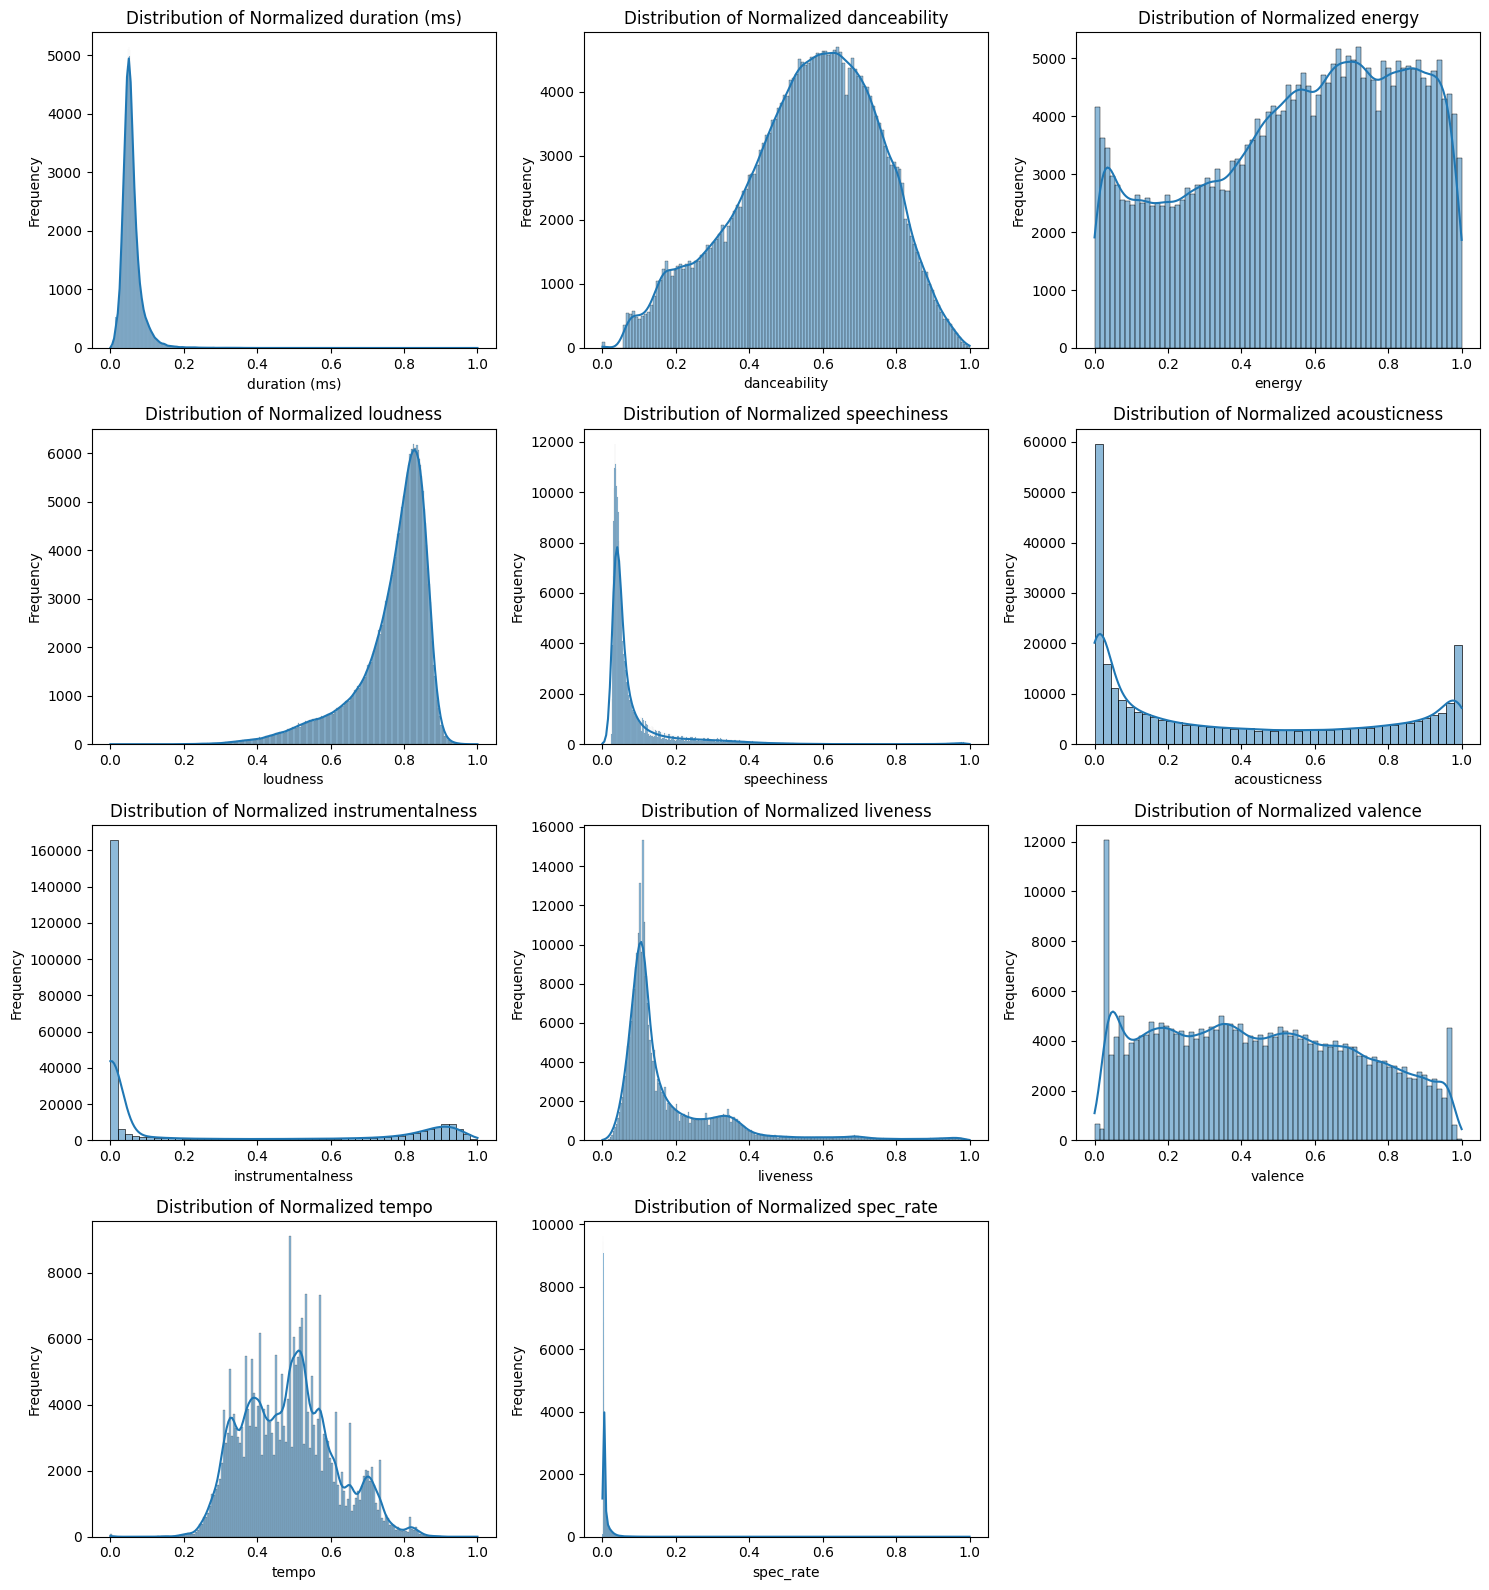

In [ ]:
# ---  Select Features ---
# Assuming your label is the 12th column (index 11)
features = df_song_feature.iloc[:, :11]
label = df_song_feature.iloc[:, 11] # If you need to keep the label separate

# ---  Normalize Data ---
# We'll use MinMaxScaler to scale features between 0 and 1.
# You could also use StandardScaler for z-score normalization.
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(features)

# Convert the normalized array back to a DataFrame for easier plotting
normalized_df = pd.DataFrame(normalized_features, columns=features.columns)

# ---  Visualize Distributions ---

# Set up the plotting environment
# We'll create a figure with subplots, one for each feature
n_features = normalized_df.shape[1]
n_cols = 3 # Number of columns for subplots
n_rows = (n_features + n_cols - 1) // n_cols # Calculate the number of rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # Flatten the array of axes for easy iteration

# Loop through each feature and plot its distribution
for i, col in enumerate(normalized_df.columns):
    sns.histplot(normalized_df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of Normalized {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### hist plot with label

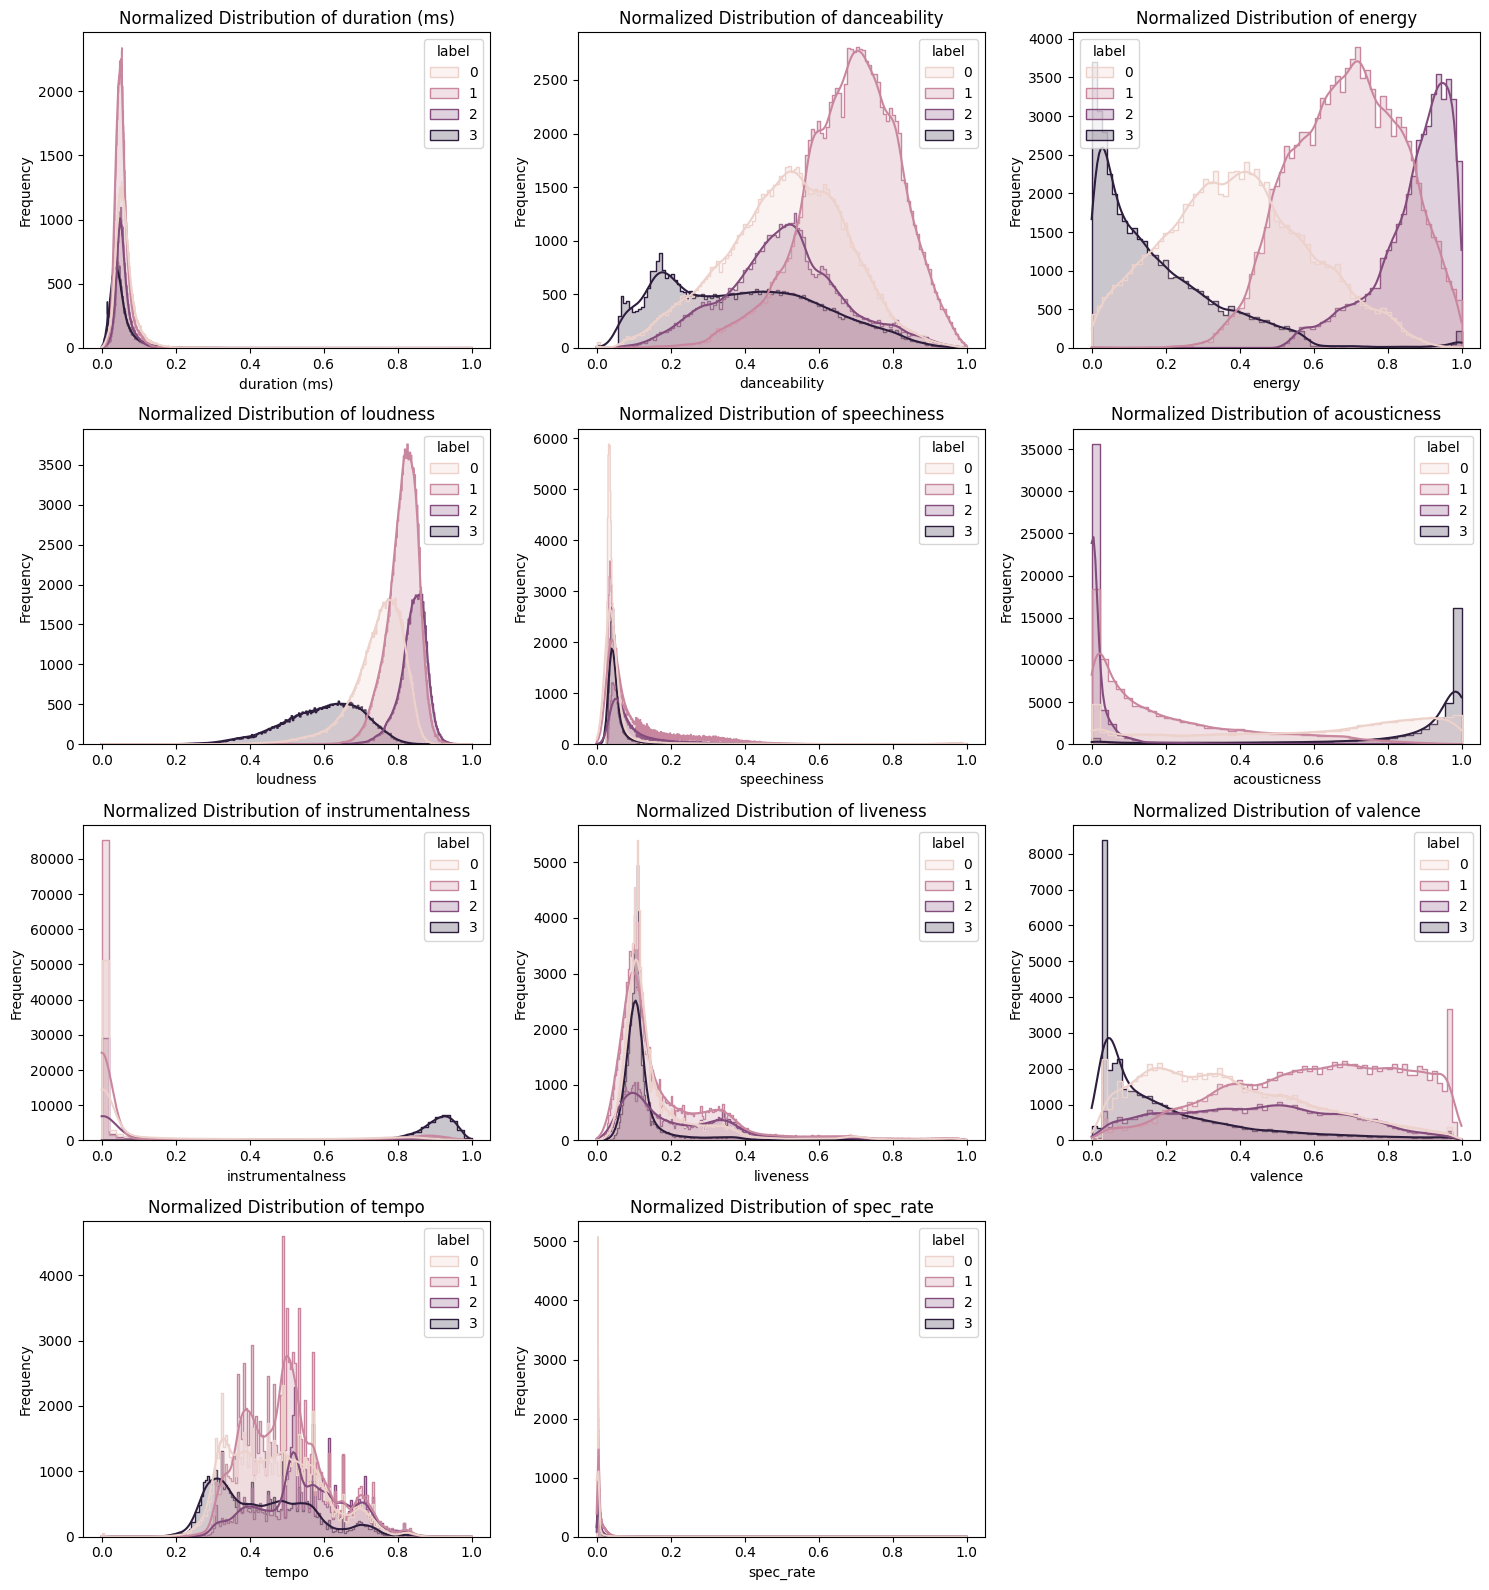

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

# 假設您的資料已經載入到一個名為 df_song_feature 的 DataFrame 中
# 如果沒有，請先使用 pd.read_csv('your_spotify_data.csv') 等方式載入
# 例如：
# df_song_feature = pd.read_csv('df_song_feature.csv')

# --- 選擇 Features ---
# 假設您的 label 是第 12 列 (index 11)
features = df_song_feature.iloc[:, :11]
label = df_song_feature.iloc[:, 11] # 將 label 另外取出

# --- 資料正規化 (Normalization) ---
# 我們使用 MinMaxScaler 將 features 縮放到 0 到 1 之間
# 您也可以選擇使用 StandardScaler 進行 z-score 正規化
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(features)

# 將正規化後的 numpy array 轉換回 DataFrame，方便後續繪圖
normalized_df = pd.DataFrame(normalized_features, columns=features.columns)

# --- 將 Label 添加回 DataFrame ---
# 這是為了能夠在 seaborn 的 hue 參數中使用 label
normalized_df['label'] = label

# --- 視覺化分佈圖 (包含 Label) ---

# 設定繪圖環境
# 我們將建立一個包含子圖的 figure，每個 feature 一個子圖
n_features = normalized_df.shape[1] - 1  # 減去 'label' 欄位
n_cols = 3  # 子圖的欄數
# 計算需要的列數
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # 將 axes 陣列展平，方便迭代

# 迴圈遍歷每個 feature 並繪製其分佈圖
for i, col in enumerate(features.columns):
    sns.histplot(data=normalized_df, x=col, hue='label', kde=True, ax=axes[i], element="step")
    axes[i].set_title(f'Normalized Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# 移除未使用的子圖
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # 調整子圖佈局，避免重疊
plt.savefig('spotify_feature_distributions_with_labels.png') # 儲存圖片
plt.show()

### density plot with label

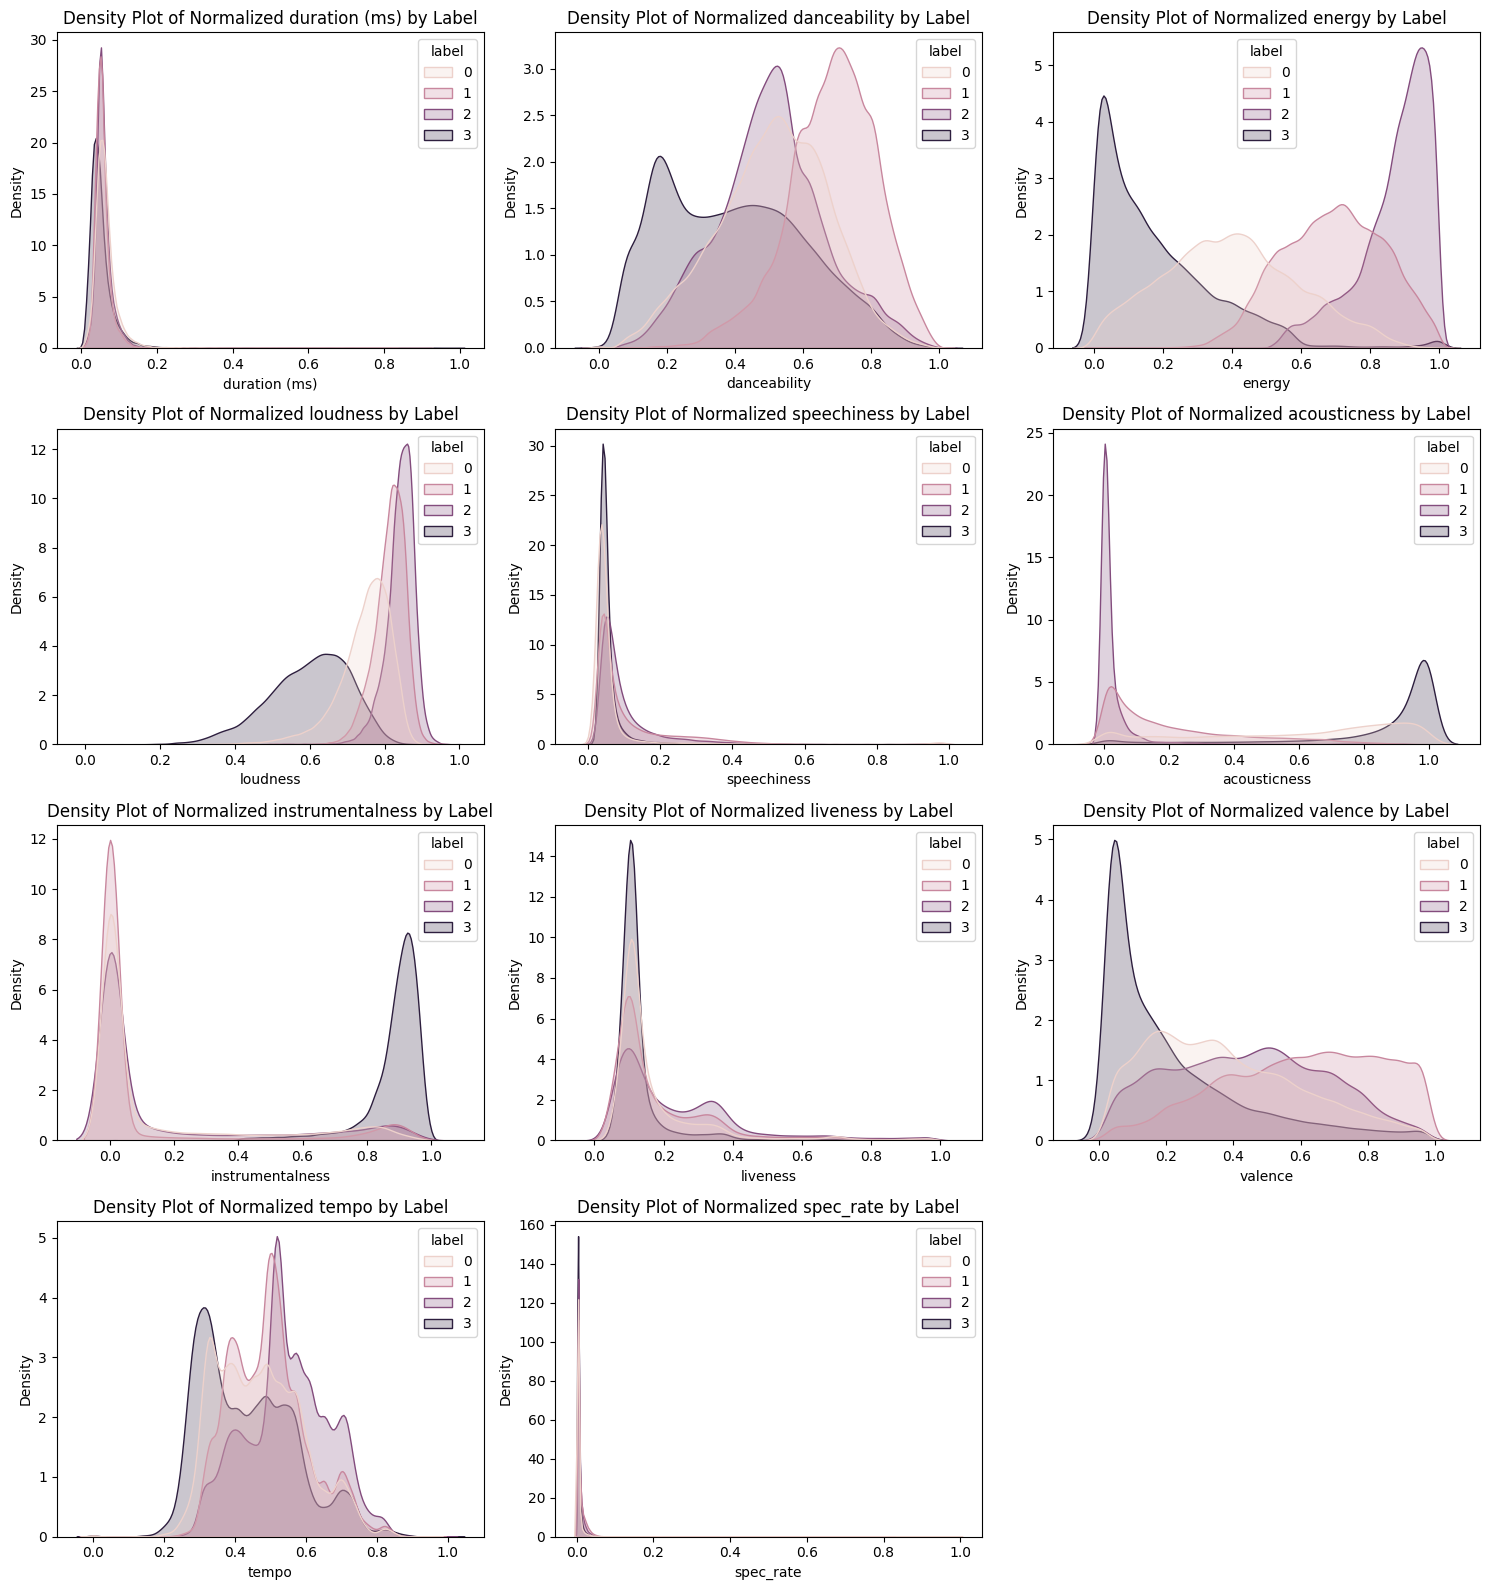

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

# --- 假設您已讀取 df_song_feature ---
# df_song_feature = pd.read_csv('your_data.csv') # 請替換為您的檔案路徑

# --- Select Features ---
features = df_song_feature.iloc[:, :11]
label = df_song_feature.iloc[:, 11]

# --- Normalize Data ---
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(features)

# Convert the normalized array back to a DataFrame
normalized_df = pd.DataFrame(normalized_features, columns=features.columns)

# --- Add label to the normalized DataFrame for plotting ---
normalized_df['label'] = label

# --- Visualize Distributions with Labels ---

n_features = normalized_df.shape[1] - 1 # Exclude the 'label' column itself
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

# Loop through each feature and plot its distribution, differentiated by label
for i, col in enumerate(features.columns):
    sns.kdeplot(data=normalized_df, x=col, hue='label', fill=True, common_norm=False, ax=axes[i])
    # common_norm=False is often useful when comparing distributions of different sized groups
    # fill=True helps visualize the area under the curve
    axes[i].set_title(f'Density Plot of Normalized {col} by Label')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## feature extraction
1. PCA (只做這個)
2. t-SNE
3. UNET
4. NMD

### PCA dimension reduction - data split and normalization
https://towardsdatascience.com/principal-component-regression-clearly-explained-and-implemented-608471530a2f
https://hackmd.io/@joanne8826/
https://medium.com/data-science-navigator/pca-%E9%99%8D%E7%B6%AD-85f0e34c6b
https://leemeng.tw/essence-of-principal-component-analysis.html
https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA

df = pd.read_csv('./Data/278k_song_labelled.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
target = 'labels'
X = df.drop(target,axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Run standardization on X variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### modeling without feature extraction
* regression 的模型會用 MSE(mean square error), RMSE(root mean square error), MAE(mean absolute error), R squaure 來評估模型    
但我目前的應用，是類別型的資料，需要使用分類模型而不是迴歸模型。    
因此評估方式會用accuracy, precision, recall , f1 score, auc-roc     

##### 嘗試用回歸類型的模型來看看

In [17]:
# 定義交叉驗證折疊
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# 定義要評估的模型
# 由於 LassoCV 和 RidgeCV 已經內建了交叉驗證來選擇最佳參數，
# 這裡我們主要展示如何組織程式碼
models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': LassoCV(),
    'Ridge Regression': RidgeCV()
}

# 儲存結果的字典
results = {}

# 迴圈遍歷所有模型
for name, model in models.items():
    print(f"--- 評估 {name} ---")

    # 訓練模型並評估
    model.fit(X_train_scaled, y_train)

    # 交叉驗證分數（訓練集）
    # 注意：LassoCV 和 RidgeCV 內部已經處理了交叉驗證，所以這裡的 cross_val_score 其實是額外的，
    # 但為了與 LinearRegression 保持一致，我們可以這樣寫。
    # 實際上，LassoCV 和 RidgeCV 擬合後，會自動選擇最佳的 alpha 值。
    train_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='neg_root_mean_squared_error')
    train_rmse = -1 * train_scores.mean()

    # 測試集分數
    y_pred = model.predict(X_test_scaled)
    test_rmse = mean_squared_error(y_test, y_pred)

    # 將結果存入字典
    results[name] = {
        'Train RMSE (CV)': train_rmse,
        'Test RMSE': test_rmse,
        'R-squared': model.score(X_test_scaled, y_test)
    }

    print(f"訓練集 RMSE (CV): {train_rmse:.4f}")
    print(f"測試集 RMSE: {test_rmse:.4f}")
    print("-" * 20)

# 顯示所有結果
print("所有模型評估結果：")
for name, scores in results.items():
    print(f"{name}:")
    for key, value in scores.items():
        print(f"  {key}: {value:.4f}")
    print("")

--- 評估 Linear Regression ---
訓練集 RMSE (CV): 0.7860
測試集 RMSE: 0.6153
--------------------
--- 評估 Lasso Regression ---
訓練集 RMSE (CV): 0.7860
測試集 RMSE: 0.6153
--------------------
--- 評估 Ridge Regression ---
訓練集 RMSE (CV): 0.7860
測試集 RMSE: 0.6153
--------------------
所有模型評估結果：
Linear Regression:
  Train RMSE (CV): 0.7860
  Test RMSE: 0.6153
  R-squared: 0.4087

Lasso Regression:
  Train RMSE (CV): 0.7860
  Test RMSE: 0.6153
  R-squared: 0.4087

Ridge Regression:
  Train RMSE (CV): 0.7860
  Test RMSE: 0.6153
  R-squared: 0.4087



##### classification model

In [ ]:

logistic regression 大概20分鐘就可以運行完畢
svm 運行10個小時都不行， 難道是cv 設定太大？
在svm 使用 svc 是implement based on libsvm 。在官方文件上說明，如果是比較大的資料集（比較大的定義是？）
可以優先考慮linerSVC 和 SGDClassifier
xgboost 遇到 32位元的python 跑在64位元os的問題
random forest 
naive bayes

##### 10 cv  + 每個模型都存

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
#import xgboost as xgb # 啟用 XGBoost
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
import joblib # 引入 joblib 用於儲存模型
import os # 用於創建目錄

# --- 模擬資料載入與預處理 ---
# 請確保你的 './Data/278k_song_labelled.csv' 檔案存在，
# 或確保模擬數據的創建部分能正確運行。
# 為了讓程式碼可以獨立運行，這裡會模擬數據，請根據你的實際情況替換。
try:
    # 嘗試讀取實際數據
    df = pd.read_csv('./Data/278k_song_labelled.csv')
    if 'Unnamed: 0' in df.columns: # 移除可能的 index column
        df.drop(columns=['Unnamed: 0'], inplace=True)
    
    target = 'labels' # 假設你的 label 欄位名稱
    if target not in df.columns:
        raise ValueError(f"Label column '{target}' not found in the DataFrame.")
        
    X = df.drop(target, axis=1)
    y = df[target]

    # 對於分類問題，建議使用 stratify 來保持類別比例
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 標準化特徵
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 如果你使用了 PCA (例如 best_pc_num = 7)，則在此處使用 PCA
    # pca = PCA(n_components=7) 
    # X_train_input = pca.fit_transform(X_train_scaled)
    # X_test_input = pca.transform(X_test_scaled)
    
    # 如果不使用 PCA，則直接使用標準化後的數據
    X_train_input = X_train_scaled 
    X_test_input = X_test_scaled
    
    print("成功載入並處理了實際數據。")

except FileNotFoundError:
    print("警告: 找不到 './Data/278k_song_labelled.csv'。將使用模擬數據。")
    from sklearn.datasets import make_classification
    # 模擬數據
    n_samples = 500 # 增加樣本數讓模型表現更穩定
    n_features = 11 # 模擬 11 個特徵
    n_classes = 4   # 模擬 4 分類問題
    X_sim, y_sim = make_classification(
        n_samples=n_samples, 
        n_features=n_features, 
        n_informative=5, 
        n_redundant=2, 
        n_classes=n_classes, 
        n_clusters_per_class=2,
        random_state=42
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_sim, y_sim, test_size=0.2, random_state=42, stratify=y_sim
    )
    
    # 標準化模擬數據
    scaler = StandardScaler()
    X_train_input = scaler.fit_transform(X_train)
    X_test_input = scaler.transform(X_test)
    print("已創建模擬數據。")

except ValueError as ve:
    print(f"數據處理錯誤: {ve}")
    print("請檢查你的 CSV 檔案和欄位名稱。")
    exit() # 停止程式碼執行

# ----------------------------------------------

# 定義交叉驗證折疊
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# 建立模型名稱到模型的映射
# Logisitic Regression: 適合線性可分或近似線性可分的數據，或作為基準模型
# SVC: 強大的分類器，對於高維數據和非線性關係表現良好
# RandomForestClassifier: 集合模型，通常具有很好的泛化能力，不易過擬合
# XGBoost: 高效的梯度提升模型，通常在多種任務上表現最佳，但需要正確的環境配置
models = {
    'Logistic Regression': LogisticRegression(multi_class='auto', solver='liblinear', random_state=42, max_iter=200), # 增加max_iter以防收斂問題
    #'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42), # kernel='rbf' 是常見的選擇
    'Linear Support Vector Machine':LinearSVC(random_state=42, dual='auto', max_iter=2000), # dual='auto避免警告
    #'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'), # class_weight='balanced' 有助於類別不平衡
    'Gaussian Naive Bayes':GaussianNB(),
    #'XGBoost': xgb.XGBClassifier(objective='multi:softprob', num_class=len(np.unique(y_train)), eval_metric='mlogloss', use_label_encoder=False, random_state=42) # 確保 XGBoost 設定正確
}

# 創建模型儲存目錄
model_dir = 'model'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"已創建模型儲存目錄: '{model_dir}'")

# --- 進行模型評估與訓練 ---
for name, model in models.items():
    # 儲存結果和最佳模型的相關資訊
    results = {}
    best_model_info = {
        'name': None,
        'model': None,
        'test_accuracy': -1,
        'test_f1_macro': -1,
        'test_conf_matrix': None,
        'test_report': None
    }
    print(f"--- 評估模型: {name} ---")

    # 創建 Pipeline (包含預處理，例如 StandardScaler)
    # 如果你使用了 PCA，可以在這裡加入 PCA 步驟
    # pipeline = Pipeline([
    #     ('scaler', StandardScaler()), # 如果 X_train_input 還沒標準化
    #     # ('pca', PCA(n_components=best_pc_num)), # 如果 PCA 是要與模型一起套用
    #     ('classifier', model)
    # ])
    
    # 由於我們已經提前做了標準化和 PCA (如果有的話)，這裡直接使用 X_train_input
    # 如果要將 PCA 納入 Pipeline，則 X_train_input 應為 X_train_scaled
    # pipeline = Pipeline([('pca', PCA(n_components=7)), ('classifier', model)]) # 範例: PCA + Model
    
    # 直接使用模型進行 fit 和 cross_val_score
    # 確保使用 numpy 陣列作為輸入，避免 Pandas DataFrame 的潛在問題
    X_train_np = np.array(X_train_input)
    y_train_np = np.array(y_train)
    X_test_np = np.array(X_test_input) # 測試集也轉成 numpy 陣列

    try:
        # 訓練模型
        model.fit(X_train_np, y_train_np)

        # --- 交叉驗證分數（訓練集）---
        # 準確率
        train_scores_acc = cross_val_score(model, X_train_np, y_train_np, cv=cv, scoring='accuracy')
        train_accuracy = train_scores_acc.mean()
        
        # F1-macro 分數 (對類別不平衡更穩健)
        train_scores_f1 = cross_val_score(model, X_train_np, y_train_np, cv=cv, scoring='f1_macro')
        train_f1_macro = train_scores_f1.mean()

        # --- 測試集評估 ---
        y_pred = model.predict(X_test_np)
        test_accuracy = accuracy_score(y_test, y_pred)
        test_f1_macro = f1_score(y_test, y_pred, average='macro')
        
        # 混淆矩陣
        conf_matrix = confusion_matrix(y_test, y_pred)
        
        # 分類報告 (包含 precision, recall, f1-score per class)
        class_report = classification_report(y_test, y_pred, zero_division=0)

        # --- 儲存結果 ---
        results[name] = {
            'Train Accuracy (CV)': train_accuracy,
            'Train F1-macro (CV)': train_f1_macro,
            'Test Accuracy': test_accuracy,
            'Test F1-macro': test_f1_macro,
            'Confusion Matrix': conf_matrix,
            'Classification Report': class_report
        }

        print(f"訓練集 Accuracy (CV): {train_accuracy:.4f}")
        print(f"訓練集 F1-macro (CV): {train_f1_macro:.4f}")
        print(f"測試集 Accuracy: {test_accuracy:.4f}")
        print(f"測試集 F1-macro: {test_f1_macro:.4f}")
        # print(f"混淆矩陣:\n{conf_matrix}\n") # 混淆矩陣較大，這裡不直接印出
        # print(f"分類報告:\n{class_report}")

        # --- 檢查並儲存最佳模型 ---
        # 我們以 Test Accuracy 作為主要的判斷標準，F1-macro 作為輔助
        if test_accuracy > best_model_info['test_accuracy']:
            best_model_info['name'] = name
            best_model_info['model'] = model # 儲存已擬合的模型
            best_model_info['test_accuracy'] = test_accuracy
            best_model_info['test_f1_macro'] = test_f1_macro
            best_model_info['test_conf_matrix'] = conf_matrix
            best_model_info['test_report'] = class_report
            
            # 儲存模型
            model_filename = os.path.join(model_dir, f"{name.replace(' ', '_')}_best_model.joblib")
            joblib.dump(model, model_filename)
            print(f"** 新的最佳模型找到！已儲存 '{name}' 模型至 '{model_filename}' **")
        
    except Exception as e:
        print(f"模型 {name} 評估時發生錯誤: {e}")
        # 如果是 XGBoost 的環境問題，會在這裡捕獲
        if "XGBoost Library" in str(e) and name == 'XGBoost':
            print("=> XGBoost 載入失敗，請檢查你的 XGBoost 環境設置 (如 libomp)。")
        results[name] = {
            'Error': str(e)
        }
    
    print("-" * 30)

# --- 顯示所有結果總結 ---
print("\n" + "="*30)
print("所有模型評估結果總結：")
print("="*30)
for name, scores in results.items():
    print(f"{name}:")
    if 'Error' in scores:
        print(f"  Error: {scores['Error']}")
    else:
        for key, value in scores.items():
            if key == 'Confusion Matrix':
                print(f"  {key}:\n{value}")
            elif key == 'Classification Report':
                print(f"  {key}:\n{value}")
            else:
                print(f"  {key}: {value:.4f}")
    print("")

# --- 顯示表現最好的模型資訊 ---
print("\n" + "="*40)
print("表現最好的模型資訊：")
print("="*40)
if best_model_info['name']:
    print(f"模型名稱: {best_model_info['name']}")
    print(f"測試集準確率 (Accuracy): {best_model_info['test_accuracy']:.4f}")
    print(f"測試集巨集平均 F1 分數 (F1-macro): {best_model_info['test_f1_macro']:.4f}")
    print(f"儲存路徑: model/{best_model_info['name'].replace(' ', '_')}_best_model.joblib")
    print(f"混淆矩陣:\n{best_model_info['test_conf_matrix']}")
    print(f"分類報告:\n{best_model_info['test_report']}")
else:
    print("未能找到表現最佳的模型（可能所有模型都出現錯誤）。")

成功載入並處理了實際數據。
--- 評估模型: Logistic Regression ---


/opt/anaconda3/envs/spotify_emo/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/spotify_emo/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/envs/spotify_emo/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.war

訓練集 Accuracy (CV): 0.8075
訓練集 F1-macro (CV): 0.8138
測試集 Accuracy: 0.8068
測試集 F1-macro: 0.8131
** 新的最佳模型找到！已儲存 'Logistic Regression' 模型至 'model/Logistic_Regression_best_model.joblib' **
------------------------------
--- 評估模型: Linear Support Vector Machine ---
訓練集 Accuracy (CV): 0.8041
訓練集 F1-macro (CV): 0.8095
測試集 Accuracy: 0.8037
測試集 F1-macro: 0.8091
** 新的最佳模型找到！已儲存 'Linear Support Vector Machine' 模型至 'model/Linear_Support_Vector_Machine_best_model.joblib' **
------------------------------
--- 評估模型: Gaussian Naive Bayes ---
訓練集 Accuracy (CV): 0.7948
訓練集 F1-macro (CV): 0.8032
測試集 Accuracy: 0.7922
測試集 F1-macro: 0.8012
** 新的最佳模型找到！已儲存 'Gaussian Naive Bayes' 模型至 'model/Gaussian_Naive_Bayes_best_model.joblib' **
------------------------------

所有模型評估結果總結：
Gaussian Naive Bayes:
  Train Accuracy (CV): 0.7948
  Train F1-macro (CV): 0.8032
  Test Accuracy: 0.7922
  Test F1-macro: 0.8012
  Confusion Matrix:
[[11953  2754   832   873]
 [ 1307 16309  3622    48]
 [  138  1318  7948     9]
 [  579

##### 在程式碼上面進行超參數的尋找。


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC # 引入 LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
import joblib
import os

# --- 模擬資料載入與預處理 (與你提供的程式碼相同) ---
try:
    df = pd.read_csv('./Data/278k_song_labelled.csv')
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)
    target = 'labels'
    if target not in df.columns:
        raise ValueError(f"Label column '{target}' not found in the DataFrame.")
    X = df.drop(target, axis=1)
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_train_input = X_train_scaled
    X_test_input = X_test_scaled
    print("成功載入並處理了實際數據。")
except FileNotFoundError:
    print("警告: 找不到 './Data/278k_song_labelled.csv'。將使用模擬數據。")
    from sklearn.datasets import make_classification
    n_samples = 500
    n_features = 11
    n_classes = 4
    X_sim, y_sim = make_classification(n_samples=n_samples, n_features=n_features, n_informative=5, n_redundant=2, n_classes=n_classes, n_clusters_per_class=2, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X_sim, y_sim, test_size=0.2, random_state=42, stratify=y_sim)
    scaler = StandardScaler()
    X_train_input = scaler.fit_transform(X_train)
    X_test_input = scaler.transform(X_test)
    print("已創建模擬數據。")
except ValueError as ve:
    print(f"數據處理錯誤: {ve}")
    exit()

# 確保輸入是 NumPy 陣列
X_train_np = np.array(X_train_input)
y_train_np = np.array(y_train)
X_test_np = np.array(X_test_input)
y_test_np = np.array(y_test) # 確保測試集的 y 也是 numpy 陣列

# 定義交叉驗證折疊 (用於 GridSearchCV)
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42) # 調整 CV 折數，5折較常用於 GridSearch

# 定義模型及其超參數搜索空間
# 注意：對於線性模型，solver='liblinear' 不支援 class_weight='balanced'
# LogisticRegression 的 solver='saga' 或 'lbfgs' 支援 class_weight='balanced'
model_configs = {
    'Logistic Regression': {
        'model': LogisticRegression(multi_class='auto', random_state=42, max_iter=500), # 增加 max_iter
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'solver': ['liblinear', 'saga'], # liblinear for smaller datasets, saga for larger ones and supports class_weight
            'class_weight': [None, 'balanced'] # 嘗試類別權重
        }
    },
    'Linear Support Vector Machine': {
        'model': LinearSVC(random_state=42, dual='auto', max_iter=2000), # dual='auto' 避免警告
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2'],
            'class_weight': [None, 'balanced']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [20, 40, 60], # 較少的estimators用於快速測試
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5,],
            'min_samples_leaf': [1, 2],
            'class_weight': [None, 'balanced']
        }
    },
    'Gaussian Naive Bayes': {
        'model': GaussianNB(),
        'params': {} # Naive Bayes 通常沒有太多需要調優的超參數
    }
}

# 儲存所有模型的最佳模型和結果
all_best_models = {}
results_summary = {}

# 創建模型儲存目錄
model_dir = 'saved_models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"已創建模型儲存目錄: '{model_dir}'")

print("\n" + "="*40)
print("開始進行模型訓練與超參數調優")
print("="*40)

for name, config in model_configs.items():
    print(f"--- 正在處理模型: {name} ---")

    model_estimator = config['model']
    param_grid = config['params']

    # 使用 GridSearchCV 進行超參數調優
    # scoring='accuracy' 是預設，也可以指定 'f1_macro'
    grid_search = GridSearchCV(
        estimator=model_estimator,
        param_grid=param_grid,
        cv=cv_splitter, # 使用 KFold 分割
        scoring='accuracy', # 或 'f1_macro'，取決於你更看重什麼
        n_jobs=-1, # 使用所有可用的 CPU 核心
        verbose=1 # 顯示進度
    )

    try:
        # 訓練模型並尋找最佳參數
        grid_search.fit(X_train_np, y_train_np)

        # 獲取最佳模型和其參數
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_cv_score = grid_search.best_score_ # 這是交叉驗證的平均分數

        # 在整個訓練集上重新訓練最佳模型 (GridSearchCV 已經替我們做了這件事，`best_estimator_` 就是用所有訓練資料訓練好的)
        # 所以 `best_model` 就是我們想要的最終模型

        # --- 在測試集上評估最佳模型 ---
        y_pred = best_model.predict(X_test_np)
        test_accuracy = accuracy_score(y_test_np, y_pred)
        test_f1_macro = f1_score(y_test_np, y_pred, average='macro', zero_division=0)
        conf_matrix = confusion_matrix(y_test_np, y_pred)
        class_report = classification_report(y_test_np, y_pred, zero_division=0)

        # --- 儲存結果 ---
        results_summary[name] = {
            'Best CV Accuracy': best_cv_score,
            'Best Params': best_params,
            'Test Accuracy': test_accuracy,
            'Test F1-macro': test_f1_macro,
            'Confusion Matrix': conf_matrix,
            'Classification Report': class_report
        }

        print(f"模型: {name}")
        print(f"  最佳交叉驗證準確率: {best_cv_score:.4f}")
        print(f"  最佳超參數: {best_params}")
        print(f"  測試集準確率: {test_accuracy:.4f}")
        print(f"  測試集 F1-macro: {test_f1_macro:.4f}")

        # --- 儲存最佳模型 ---
        model_filename = os.path.join(model_dir, f"{name.replace(' ', '_')}_best_model.joblib")
        joblib.dump(best_model, model_filename) # 儲存已找到最佳參數的模型
        print(f"  已儲存最佳模型至: '{model_filename}'")

        # 為了方便之後比較，我們也可以儲存每個模型架構的整體表現
        all_best_models[name] = {
            'model': best_model,
            'params': best_params,
            'cv_score': best_cv_score,
            'test_accuracy': test_accuracy,
            'test_f1_macro': test_f1_macro
        }

    except Exception as e:
        print(f"模型 {name} 訓練或調優時發生錯誤: {e}")
        results_summary[name] = {
            'Error': str(e)
        }
    print("-" * 30)

# --- 顯示所有結果總結 ---
print("\n" + "="*40)
print("所有模型超參數調優結果總結：")
print("="*40)
for name, metrics in results_summary.items():
    print(f"{name}:")
    if 'Error' in metrics:
        print(f"  Error: {metrics['Error']}")
    else:
        print(f"  最佳交叉驗證準確率: {metrics['Best CV Accuracy']:.4f}")
        print(f"  最佳超參數: {metrics['Best Params']}")
        print(f"  測試集準確率: {metrics['Test Accuracy']:.4f}")
        print(f"  測試集 F1-macro: {metrics['Test F1-macro']:.4f}")
        # print(f"  混淆矩陣:\n{metrics['Confusion Matrix']}") # 較長，可選印出
        # print(f"  分類報告:\n{metrics['Classification Report']}") # 較長，可選印出
    print("")

# --- 找到表現最好的模型 (基於測試集準確率) ---
print("\n" + "="*40)
print("整體表現最好的模型 (基於測試集準確率)：")
print("="*40)

best_overall_model_name = None
best_overall_test_accuracy = -1

for name, info in all_best_models.items():
    if info['test_accuracy'] > best_overall_test_accuracy:
        best_overall_test_accuracy = info['test_accuracy']
        best_overall_model_name = name

if best_overall_model_name:
    best_model_details = all_best_models[best_overall_model_name]
    print(f"模型名稱: {best_overall_model_name}")
    print(f"最佳超參數: {best_model_details['params']}")
    print(f"交叉驗證準確率: {best_model_details['cv_score']:.4f}")
    print(f"測試集準確率: {best_model_details['test_accuracy']:.4f}")
    print(f"測試集 F1-macro: {best_model_details['test_f1_macro']:.4f}")
    file_name = f"{best_overall_model_name.replace(' ', '_')}_best_model.joblib"
    print(f"儲存路徑: {os.path.join(model_dir, file_name)}")
    #print(f"最終訓練的混淆矩陣:\n{best_model_details['Confusion Matrix']}")
    #print(f"最終訓練的分類報告:\n{best_model_details['Classification Report']}")
else:
    print("未能找到整體表現最好的模型。")

成功載入並處理了實際數據。

開始進行模型訓練與超參數調優
--- 正在處理模型: Logistic Regression ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/anaconda3/envs/spotify_emo/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/spotify_emo/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/spotify_emo/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/spotify_emo/lib/python3.11/site-packages/sklearn/linear_model/

模型: Logistic Regression
  最佳交叉驗證準確率: 0.8392
  最佳超參數: {'C': 10, 'class_weight': None, 'solver': 'saga'}
  測試集準確率: 0.8388
  測試集 F1-macro: 0.8453
  已儲存最佳模型至: 'saved_models/Logistic_Regression_best_model.joblib'
------------------------------
--- 正在處理模型: Linear Support Vector Machine ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
模型: Linear Support Vector Machine
  最佳交叉驗證準確率: 0.8041
  最佳超參數: {'C': 10, 'class_weight': None, 'penalty': 'l1'}
  測試集準確率: 0.8037
  測試集 F1-macro: 0.8091
  已儲存最佳模型至: 'saved_models/Linear_Support_Vector_Machine_best_model.joblib'
------------------------------
--- 正在處理模型: Random Forest ---
Fitting 5 folds for each of 72 candidates, totalling 360 fits
模型: Random Forest
  最佳交叉驗證準確率: 0.9407
  最佳超參數: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 60}
  測試集準確率: 0.9415
  測試集 F1-macro: 0.9423
  已儲存最佳模型至: 'saved_models/Random_Forest_best_model.joblib'
------------------------------
--- 正在處理模型: Gauss

KeyError: 'Confusion Matrix'

#### 透過pca 來降維
主要討論，如果降維的時候，我們應該怎麼選擇要降到幾維？
因為目前的模型表現大概就是上面呈現的樣子。
基本上有幾個做法，
* feature extraction
* feature selection
* tree-based 來挑feature
* SHAP 來看 feature的貢獻程度

In [14]:
from sklearn.decomposition import PCA
# Generate all the principal components
pca = PCA() # Default n_components = min(n_samples, n_features)
X_train_pc = pca.fit_transform(X_train_scaled) #NOTE: 預測的情況下，會產生跟feature數量相同的維度。

# View first 5 rows of all principal components
pd.DataFrame(pca.components_.T).head()

,0,1,2,3,4,5,6,7,8,9,10
0,-0.022250,-0.221111,0.446634,-0.519791,-0.589747,0.322933,-0.038403,-0.036088,0.012557,0.160104,0.017194
1,0.312283,0.067369,-0.482053,-0.216715,-0.179529,0.130712,0.300226,0.670098,0.004179,0.057831,0.163569
2,0.460265,-0.129316,0.208374,0.029523,0.039640,-0.236334,0.189456,-0.241401,0.210236,-0.080628,0.724465
3,0.465405,-0.155931,0.052908,-0.027945,0.040426,-0.177756,-0.118366,0.042145,0.645180,0.105697,-0.528258
4,0.160831,0.623789,0.145506,-0.068531,-0.267549,-0.024811,-0.042287,-0.017706,0.047002,-0.686247,-0.108202


##### pca.explained_variance_ratio_ 的解釋

* 什麼是變異性 (Variance)？ 

    在統計學中，變異性衡量了一組數據點的離散程度。高變異性表示數據點分散得比較開，低變異性則表示數據點比較集中。在 PCA 中，我們關心的是數據的總變異性，因為它代表了數據中的總資訊量。

* 什麼是解釋變異性比例 (Explained Variance Ratio)？ 

    PCA 的目標是找到能夠捕捉原始數據最多變異性的新座標軸（即主成分）。

    explained_variance_ratio_ 是一個 NumPy 陣列，其長度等於你產生的主成分數量。

    陣列中的每個值都是一個介於 0 和 1 之間的浮點數，代表了對應主成分解釋了總變異性的百分比。

    例如，如果 explained_variance_ratio_[0] 是 0.5，則表示第一個主成分解釋了原始數據總變異性的 50%。如果 explained_variance_ratio_[1] 是 0.2，則第二個主成分解釋了 20%。

    所有 explained_variance_ratio_ 的總和會趨近於 1（或 100%），因為 PCA 找到的主成分涵蓋了原始數據的所有變異性。

* 為什麼在 PCA 降維上要探討變異性？
在 PCA 降維中，探討變異性至關重要，原因如下：

* 評估降維效果與資訊保留:

    PCA 的核心思想是保留最重要的資訊，同時減少特徵的數量。

    透過檢視 explained_variance_ratio_，你可以決定保留多少個主成分才能保留大部分的原始數據變異性。例如，你可能會發現前 5 個主成分加起來就解釋了 90% 的變異性，那麼你就可以考慮將數據降維到 5 維，而丟失的資訊相對較少。

    如果某個主成分解釋的變異性非常小（例如小於 1%），則丟棄該主成分對數據資訊的影響可能微乎其微。

* 選擇合適的主成分數量 (n_components):

    PCA() 預設會產生與原始特徵數量相同的主成分，這並沒有實現降維。

    在實際應用中，你通常會設定 n_components 的值，例如 pca = PCA(n_components=k)，其中 k 是你想保留的主成分數量。

    explained_variance_ratio_ 幫助你做出這個決定。你可以繪製一個「碎石圖 (Scree Plot)」，將累積解釋變異性 (Cumulative Explained Variance) 對主成分數量的圖。
    
    從這個圖中，你可以找到一個「肘部」，即累積變異性增加率開始顯著變緩的位置，這通常是選擇 k 的一個良好指標。

* 理解數據結構:

    explained_variance_ratio_ 也能幫助你了解原始數據的複雜度和冗餘度。如果前幾個主成分就解釋了大部分的變異性，這可能意味著原始數據中的很多特徵是相關的（冗餘的），PCA 成功地捕捉了這些相關性，並將資訊濃縮到少數幾個主成分中。



In [15]:
pca.explained_variance_ratio_

array([0.31715692, 0.16464455, 0.115282  , 0.0865252 , 0.08139969,
       0.07035755, 0.0657114 , 0.04068337, 0.02682973, 0.02039393,
       0.01101566])

#### using cumsum 來尋找想要的k

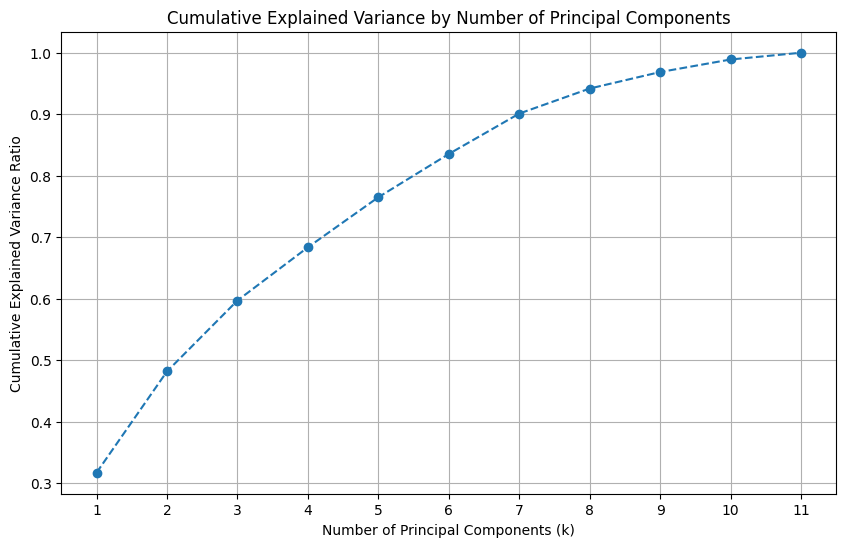

In [16]:
import matplotlib.pyplot as plt

# 假設 pca 已經 fit_transform 了 X_train_scaled
# pca = PCA().fit(X_train_scaled) # 如果你只想要變異量比例，fit 就夠了

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Number of Principal Components')
plt.xlabel('Number of Principal Components (k)')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.xticks(range(1, len(cumulative_variance) + 1)) # 確保 x 軸刻度是整數
plt.grid(True)
plt.show()

# 你可以從圖表中觀察到一個「肘部」
# 例如，如果第 10 個主成分後累積變異量達到 95%，你可能會選擇 k=10

In [17]:
target_variance = 0.95 # 例如，希望保留 95% 的變異量

# 找到第一個累積變異量超過目標值的 k
n_components = np.argmax(cumulative_variance >= target_variance) + 1
print(f"選擇 {n_components} 個主成分可以解釋 {cumulative_variance[n_components-1]:.2%} 的總變異量。")

選擇 9 個主成分可以解釋 96.86% 的總變異量。


#### 用model performance 來尋找想要的k

##### 用regression model 來找 k

In [18]:
# Initialize linear regression instance
lin_reg = LinearRegression()

# Create empty list to store RMSE for each iteration
rmse_list = []

# Loop through different count of principal components for linear regression
for i in range(1, X_train_pc.shape[1]+1):
    rmse_score = -1 * cross_val_score(lin_reg, 
                                      X_train_pc[:,:i], # Use first k principal components
                                      y_train, 
                                      cv=cv, 
                                      scoring='neg_root_mean_squared_error').mean()
    rmse_list.append(rmse_score)
    
# Visual analysis - plot RMSE vs count of principal components used
plt.plot(rmse_list, '-o')
plt.xlabel('Number of principal components in regression')
plt.ylabel('RMSE')
plt.title('Quality')
plt.xlim(xmin=-1)
plt.xticks(np.arange(X_train_pc.shape[1]), np.arange(1, X_train_pc.shape[1]+1))
plt.axhline(y=lr_score_train, color='g', linestyle='-') #NOTE: 前面訓練出來的value
print(lr_score_train)


NameError: name 'LinearRegression' is not defined

##### 用 分類模型來找k

/opt/anaconda3/envs/spotify_emo/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/spotify_emo/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/spotify_emo/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/spotify_emo/lib/python3.11/site-packages/sklearn/linear_model/

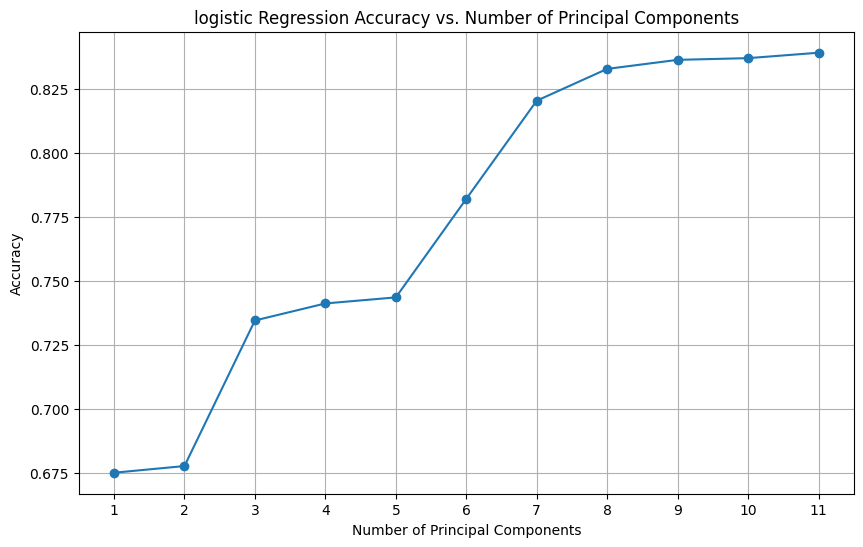

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
# 假設你已經有 X_train_pc, y_train, cv, 以及用於繪製基準線的 rf_score_train 變數


# 初始化 Random Forest 分類器
clf = LogisticRegression(multi_class='auto', random_state=42, max_iter=500, C=10, class_weight=None, solver='saga')

# 創建一個空列表來儲存準確率
accuracy_list = []

# 迴圈遍歷不同數量的主成分
for i in range(1, X_train_pc.shape[1] + 1):
    # 使用交叉驗證來評估準確率
    accuracy_score = cross_val_score(
        clf, 
        X_train_pc[:, :i],  # 使用前 i 個主成分
        y_train, 
        cv=cv, 
        scoring='accuracy'
    ).mean()
    accuracy_list.append(accuracy_score)

# 繪製準確率與主成分數量的關係圖
plt.figure(figsize=(10, 6))
plt.plot(accuracy_list, '-o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Accuracy')
plt.title('logistic Regression Accuracy vs. Number of Principal Components')
plt.xticks(np.arange(X_train_pc.shape[1]), np.arange(1, X_train_pc.shape[1] + 1))
plt.grid(True)
plt.show()

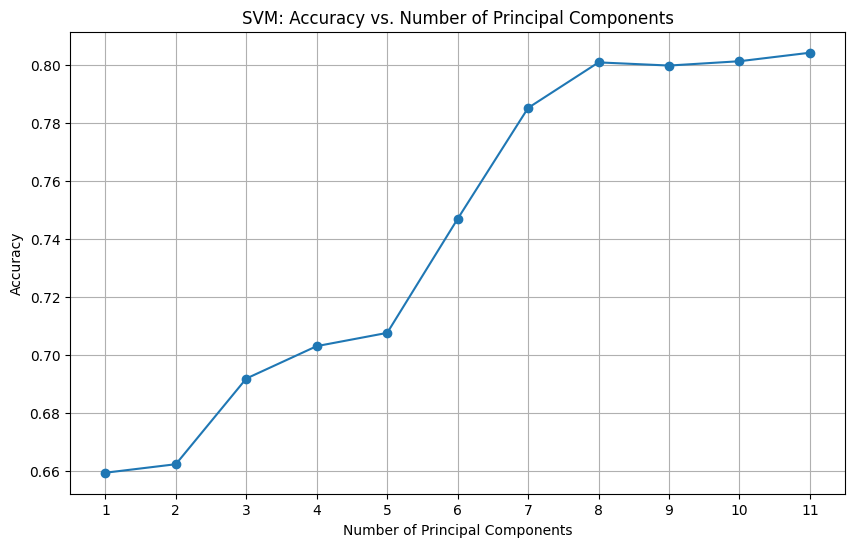

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import LinearSVC
# 假設你已經有 X_train_pc, y_train, cv, 以及用於繪製基準線的 svm_score_train 變數

# 初始化 SVM 分類器
# 這裡使用一個簡單的 SVC，你可以根據需要調整 kernel 和其他參數
svm_clf = LinearSVC(dual='auto', max_iter=2000, random_state=42, C= 10, class_weight= None, penalty='l1')

# 創建一個空列表來儲存準確率
accuracy_list_svm = []

# 迴圈遍歷不同數量的主成分
for i in range(1, X_train_pc.shape[1] + 1):
    # 使用交叉驗證來評估準確率
    accuracy_score = cross_val_score(
        svm_clf, 
        X_train_pc[:, :i],  # 使用前 i 個主成分
        y_train, 
        cv=cv, 
        scoring='accuracy'
    ).mean()
    accuracy_list_svm.append(accuracy_score)

# 繪製準確率與主成分數量的關係圖
plt.figure(figsize=(10, 6))
plt.plot(accuracy_list_svm, '-o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Accuracy')
plt.title('SVM: Accuracy vs. Number of Principal Components')
plt.xticks(np.arange(X_train_pc.shape[1]), np.arange(1, X_train_pc.shape[1] + 1))
plt.grid(True)
# 繪製基準線（使用所有特徵的準確率）
#plt.axhline(y=svm_score_train, color='g', linestyle='-') 
plt.show()

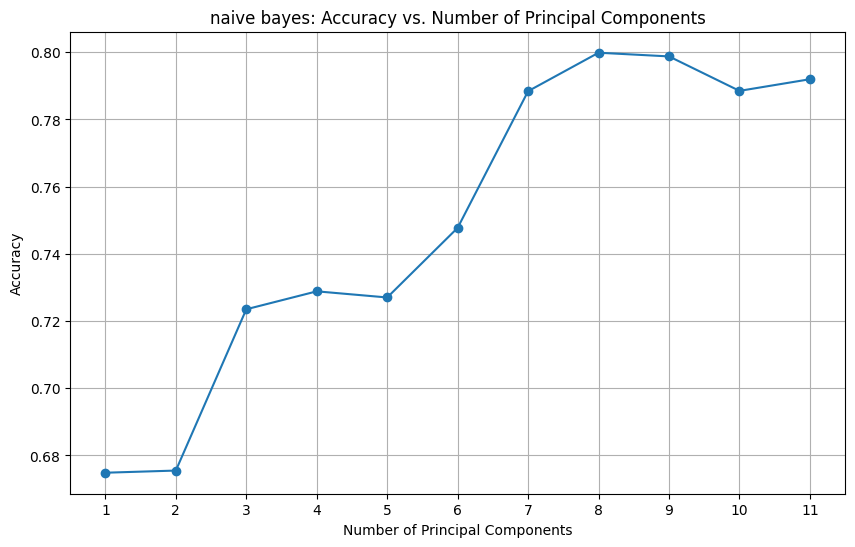

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
# 假設你已經有 X_train_pc, y_train, cv, 以及用於繪製基準線的 svm_score_train 變數

# 初始化 SVM 分類器
# 這裡使用一個簡單的 SVC，你可以根據需要調整 kernel 和其他參數
clf = GaussianNB()
# 創建一個空列表來儲存準確率
accuracy_list_svm = []

# 迴圈遍歷不同數量的主成分
for i in range(1, X_train_pc.shape[1] + 1):
    # 使用交叉驗證來評估準確率
    accuracy_score = cross_val_score(
        clf, 
        X_train_pc[:, :i],  # 使用前 i 個主成分
        y_train, 
        cv=cv, 
        scoring='accuracy'
    ).mean()
    accuracy_list_svm.append(accuracy_score)

# 繪製準確率與主成分數量的關係圖
plt.figure(figsize=(10, 6))
plt.plot(accuracy_list_svm, '-o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Accuracy')
plt.title('naive bayes: Accuracy vs. Number of Principal Components')
plt.xticks(np.arange(X_train_pc.shape[1]), np.arange(1, X_train_pc.shape[1] + 1))
plt.grid(True)
# 繪製基準線（使用所有特徵的準確率）
#plt.axhline(y=svm_score_train, color='g', linestyle='-') 
plt.show()

### 使用 svm 來進行 特徵解釋

In [ ]:
# 假設 svm_model 是一個使用線性核訓練好的 SVC 模型
# 例如：
# svm_model_linear = SVC(kernel='linear', random_state=42)
# svm_model_linear.fit(X_train_input, y_train) # 使用所有特徵

# 這裡我們假設從 X_train_input 重新訓練一個線性 SVM
svm_model_linear = SVC(kernel='linear', random_state=42)
svm_model_linear.fit(X_train_input, y_train)

if hasattr(svm_model_linear, 'coef_'):
    # 獲取線性 SVM 的權重
    # coef_ 的形狀是 (n_classes, n_features)
    # 對於二分類，形狀是 (1, n_features)
    # 對於多分類，通常取權重絕對值的平均值或進行其他處理
    
    if svm_model_linear.coef_.shape[0] == 1: # 二分類
        feature_importances_svm = np.abs(svm_model_linear.coef_[0])
    else: # 多分類，取絕對值平均
        feature_importances_svm = np.mean(np.abs(svm_model_linear.coef_), axis=0)
        
    svm_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importances_svm
    })
    svm_importance_df = svm_importance_df.sort_values('importance', ascending=False)

    print("\n--- Linear SVM Feature Importances (Coefficients) ---")
    print(svm_importance_df)

    # 繪製線性 SVM 特徵重要性圖
    plt.figure(figsize=(12, 8))
    plt.barh(svm_importance_df['feature'], svm_importance_df['importance'])
    plt.xlabel('Absolute Coefficient Value (Linear SVM)')
    plt.ylabel('Features')
    plt.title('Linear SVM Feature Importances')
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("\n該 SVM 模型沒有 'coef_' 屬性 (可能不是線性核)，無法直接獲取特徵權重。")